# ❗ 3. 의사결정나무 기반 앙상블 ❗

## 🔧 1. 환경 설정 및 라이브러리 준비

In [1]:
"""사용 라이브러리"""

# ====================
# 기본 라이브러리 import
# ====================

import pandas as pd                 # 데이터 조작 및 분석
import numpy as np                  # 수치 계산
import matplotlib.pyplot as plt     # 시각화
import seaborn as sns               # 시각화
import warnings                     # 경고 메시지 제어
from datetime import datetime       # 현재 시간
import time                         # 시간
warnings.filterwarnings('ignore')

# ====================
# 머신러닝 라이브러리
# ====================

# 데이터 전처리
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

# 의사결정나무 및 앙상블
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (RandomForestRegressor, ExtraTreesRegressor,
                            GradientBoostingRegressor, AdaBoostRegressor,
                            BaggingRegressor)

# 모델 평가 및 선택
from sklearn.model_selection import train_test_split, GridSearchCV

# 성능 지표
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# AutoML 프레임워크
import pycaret
import xgboost
import lightgbm
import catboost
from pycaret.regression import *

## 📂 2. 데이터 불러오기


### 2.1 데이터 로드

In [2]:
"""CSV 파일 불러오기"""

# # 방법 1: 로컬 파일 업로드
# from google.colab import files
# uploaded = files.upload()
# filename = list(uploaded.keys())[0]

filename = 'PBL_TAT_Set_Data_Label변환용_250627.xlsx'
df = pd.read_excel(filename,
                   skiprows=1,         # 첫 번째 행 건너뛰기
                   header=0,           # 첫 번째 행을 넘긴 후, header로 지정할 행
                   usecols="B:S"
                  )

# 방법 2: Google Drive에서 불러오기
# from google.colab import drive
# drive.mount('/content/drive')
# df = pd.read_excel('/content/drive/MyDrive/your_file.csv')

# 방법 3: 직접 불러오기
# df = pd.read_excel('/content/drive/MyDrive/your_file.csv')

print(f"✅ 데이터 로드 완료: {df.shape}")

✅ 데이터 로드 완료: (28812, 18)


In [3]:
"""불러온 파일 및 변수 분류 확인"""

# 타겟 변수와 설명 변수 분리
target_col = df.columns[-1]  # 마지막 컬럼을 타겟으로 가정
feature_cols = [col for col in df.columns if col != target_col]
numeric_features = df[feature_cols].select_dtypes(include=[np.number]).columns.tolist()
# Numerical에서 시간 변수 제외
numeric_features.remove('timekey_hr')

categorical_features = df[feature_cols].select_dtypes(include=['object', 'category']).columns.tolist()

print(f"\n🎯 변수 분류:")

print(f"   전체 변수: {list(df.columns)}")
print(f"   타겟 변수: {target_col}")
print(f"   수치형 설명 변수 ({len(numeric_features)}개): {numeric_features}")
print(f"   범주형 설명 변수 ({len(categorical_features)}개): {categorical_features}\n")
df.head()


🎯 변수 분류:
   전체 변수: ['timekey_hr', 'lot_cd', 'hbm_type', 'stack_type', 'oper', 'area', 'group', 'x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'x7', 'x8', 'x9', 'x10', 'y1']
   타겟 변수: y1
   수치형 설명 변수 (9개): ['x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'x7', 'x8', 'x9']
   범주형 설명 변수 (7개): ['lot_cd', 'hbm_type', 'stack_type', 'oper', 'area', 'group', 'x10']



,timekey_hr,lot_cd,hbm_type,stack_type,oper,area,group,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10,y1
0,2025062507,lot_cd_1,type_1,stack_1,oper_221,area_1,group_129,4800.0,199,5100,0,0,75,0,2881.0,0.018,Y,0.015565
1,2025062508,lot_cd_1,type_1,stack_1,oper_221,area_1,group_129,4800.0,275,4282,0,0,25,0,2881.0,0.002,Y,0.018498
2,2025062509,lot_cd_1,type_1,stack_1,oper_221,area_1,group_129,4800.0,325,4080,0,0,75,0,2881.0,0.011,Y,0.020275
3,2025062510,lot_cd_1,type_1,stack_1,oper_221,area_1,group_129,4800.0,325,5100,0,25,100,50,2881.0,0.011,Y,0.016809
4,2025062511,lot_cd_1,type_1,stack_1,oper_221,area_1,group_129,4800.0,176,5100,0,25,0,0,2881.0,0.002,Y,0.013434


### 2.2 데이터 변수 분류

In [4]:
# 변수 제외
def exclude_columns(df, exclude_cols):
    """
    모델링에서 제외할 변수들을 제거한 새로운 DataFrame을 반환합니다.

    Parameters:
    ----------
    df : pd.DataFrame
        원본 데이터프레임
    exclude_cols : list of str
        제외할 변수(컬럼) 이름 리스트

    Returns:
    -------
    pd.DataFrame
        제외된 변수들이 제거된 새로운 DataFrame
    """
    if not exclude_cols:
        print("⚠️ 제외할 변수가 지정되지 않았습니다. 원본 DataFrame을 반환합니다.")
        return df.copy()

    existing_cols = [col for col in exclude_cols if col in df.columns]
    missing_cols = [col for col in exclude_cols if col not in df.columns]

    if existing_cols:
        print(f"🧹 제외된 변수: {existing_cols}")
    if missing_cols:
        print(f"⚠️ 존재하지 않는 변수 (제외되지 않음): {missing_cols}")

    return df.drop(columns=existing_cols, errors='ignore')

# 범주형 변수 처리 함수
def encode_categorical_variables(df, target_col, encoding_method='onehot'):
    """
    범주형 변수들을 지정된 방식(onehot 또는 label)으로 인코딩하여 처리합니다.

    Parameters:
    ----------
    df : pd.DataFrame
        전체 입력 데이터프레임
    target_col : str
        예측 대상(타겟) 변수의 컬럼명
    encoding_method : str, default='onehot'
        인코딩 방식. 'onehot' 또는 'label' 중 선택

    Returns:
    -------
    df_processed : pd.DataFrame
        수치형 + 인코딩된 범주형 + 타겟 변수로 구성된 전처리된 데이터프레임
    """
    df_processed = df.copy()
    feature_cols = [c for c in df.columns if c != target_col]

    categorical_features = []
    numerical_features = []

    for col in feature_cols:
        if df[col].dtype.name in ['object', 'category']:
            categorical_features.append(col)
        else:
            numerical_features.append(col)

    print(f"범주형 변수: {categorical_features}")
    print(f"수치형 변수: {numerical_features}\n")
    all_features = categorical_features + numerical_features

    if categorical_features:
        if encoding_method == 'onehot':
            print("One-Hot Encoding 적용...")
            encoder = OneHotEncoder(sparse_output=False, drop='first')
            encoded_features = encoder.fit_transform(df[categorical_features])

            feature_names = []
            for i, col in enumerate(categorical_features):
                categories = encoder.categories_[i][1:]
                for cat in categories:
                    feature_names.append(f"{col}_{cat}")

            encoded_df = pd.DataFrame(encoded_features, columns=feature_names, index=df.index)
            df_processed = pd.concat([df[numerical_features], encoded_df, df[target_col]], axis=1)

        elif encoding_method == 'label':
            print("Label Encoding 적용...")
            label_encoders = {}
            for col in categorical_features:
                le = LabelEncoder()
                df_processed[col] = le.fit_transform(df[col])
                label_encoders[col] = le
                print(f"  {col}: {list(le.classes_)}")

    return df_processed, categorical_features, numerical_features, all_features

In [5]:
# 제외할 변수 설정 (예: ID, 날짜 등)
to_exclude = ['timekey_hr']

# 원본 데이터프레임에서 제외
df_filtered = exclude_columns(df, to_exclude)

🧹 제외된 변수: ['timekey_hr']


In [6]:
# 범주형 변수 인코딩
df_processed, categorical_features, numerical_features, all_features = encode_categorical_variables(df_filtered, target_col, encoding_method='label')
df_processed.head()

범주형 변수: ['lot_cd', 'hbm_type', 'stack_type', 'oper', 'area', 'group', 'x10']
수치형 변수: ['x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'x7', 'x8', 'x9']

Label Encoding 적용...
  lot_cd: ['lot_cd_1']
  hbm_type: ['type_1']


  stack_type: ['stack_1']
  oper: ['oper_1', 'oper_10', 'oper_100', 'oper_101', 'oper_102', 'oper_103', 'oper_104', 'oper_105', 'oper_106', 'oper_107', 'oper_108', 'oper_109', 'oper_11', 'oper_110', 'oper_111', 'oper_112', 'oper_113', 'oper_114', 'oper_115', 'oper_116', 'oper_117', 'oper_118', 'oper_119', 'oper_12', 'oper_120', 'oper_121', 'oper_122', 'oper_123', 'oper_124', 'oper_125', 'oper_126', 'oper_127', 'oper_128', 'oper_129', 'oper_13', 'oper_130', 'oper_131', 'oper_132', 'oper_133', 'oper_134', 'oper_135', 'oper_136', 'oper_137', 'oper_138', 'oper_139', 'oper_14', 'oper_140', 'oper_141', 'oper_142', 'oper_143', 'oper_144', 'oper_145', 'oper_146', 'oper_147', 'oper_148', 'oper_149', 'oper_15', 'oper_150', 'oper_151', 'oper_152', 'oper_153', 'oper_154', 'oper_155', 'oper_156', 'oper_157', 'oper_158', 'oper_159', 'oper_16', 'oper_160', 'oper_161', 'oper_162', 'oper_163', 'oper_164', 'oper_165', 'oper_166', 'oper_167', 'oper_168', 'oper_169', 'oper_17', 'oper_170', 'oper_171', 'op

,lot_cd,hbm_type,stack_type,oper,area,group,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10,y1
0,0,0,0,136,0,33,4800.0,199,5100,0,0,75,0,2881.0,0.018,0,0.015565
1,0,0,0,136,0,33,4800.0,275,4282,0,0,25,0,2881.0,0.002,0,0.018498
2,0,0,0,136,0,33,4800.0,325,4080,0,0,75,0,2881.0,0.011,0,0.020275
3,0,0,0,136,0,33,4800.0,325,5100,0,25,100,50,2881.0,0.011,0,0.016809
4,0,0,0,136,0,33,4800.0,176,5100,0,25,0,0,2881.0,0.002,0,0.013434


### 2.3 결측치 처리

In [7]:
# 결측치 처리

def handle_missing_values(df, method='drop', fill_value=None, strategy='mean'):
    """
    결측치 처리 함수

    Parameters:
    ----------
    df : pd.DataFrame
        처리할 데이터프레임
    method : str, default='drop'
        결측치 처리 방식:
        - 'drop' : 결측치가 포함된 행 제거
        - 'fill' : 특정 값 또는 평균/중앙값/최빈값으로 대체
        - 'interpolate' : 선형 보간법으로 대체
        - 'ffill' : 이전 값으로 대체 (forward fill)
        - 'bfill' : 이후 값으로 대체 (backward fill)
    fill_value : any, optional
        method='fill'일 때 직접 지정할 채움 값
    strategy : str, default='mean'
        fill_value가 지정되지 않은 경우 사용할 전략
        ('mean', 'median', 'mode' 중 선택)

    Returns:
    -------
    pd.DataFrame
        결측치가 처리된 데이터프레임
    """
    print(f"📊 결측치 개수:\n{df.isnull().sum()}")

    if df.isnull().sum().sum() == 0:
        print("✅ 결측치 없음")
        return df

    if method == 'drop':
        df = df.dropna()
        print("🧹 결측치가 포함된 행을 제거했습니다.")

    elif method == 'fill':
        if fill_value is not None:
            df = df.fillna(fill_value)
            print(f"📐 모든 결측치를 '{fill_value}' 값으로 대체했습니다.")
        else:
            if strategy == 'mean':
                df = df.fillna(df.mean(numeric_only=True))
                print("📐 수치형 결측치를 평균으로 대체했습니다.")
            elif strategy == 'median':
                df = df.fillna(df.median(numeric_only=True))
                print("📐 수치형 결측치를 중앙값으로 대체했습니다.")
            elif strategy == 'mode':
                df = df.fillna(df.mode().iloc[0])
                print("📐 결측치를 최빈값으로 대체했습니다.")
            else:
                raise ValueError(f"지원되지 않는 strategy: {strategy}")

    elif method == 'interpolate':
        df = df.interpolate(method='linear', limit_direction='forward')
        print("🔁 결측치를 선형 보간법으로 대체했습니다.")

    elif method == 'ffill':
        df = df.fillna(method='ffill')
        print("🔁 결측치를 이전 값으로 대체했습니다. (forward fill)")

    elif method == 'bfill':
        df = df.fillna(method='bfill')
        print("🔁 결측치를 이후 값으로 대체했습니다. (backward fill)")

    else:
        raise ValueError(f"지원되지 않는 method: {method}")
    print(f"📊 처리 후 결측치 개수:\n{df.isnull().sum()}")
    return df

df_processed = handle_missing_values(df_processed, method='ffill')

📊 결측치 개수:
lot_cd           0
hbm_type         0
stack_type       0
oper             0
area             0
group            0
x1               0
x2               0
x3               0
x4               0
x5               0
x6               0
x7               0
x8            1568
x9            1568
x10              0
y1            3503
dtype: int64
🔁 결측치를 이전 값으로 대체했습니다. (forward fill)
📊 처리 후 결측치 개수:
lot_cd        0
hbm_type      0
stack_type    0
oper          0
area          0
group         0
x1            0
x2            0
x3            0
x4            0
x5            0
x6            0
x7            0
x8            0
x9            0
x10           0
y1            0
dtype: int64


### 2.4 데이터 분할

In [8]:
print(f"\n{'='*60}")
print(f"📂 Train/Val/Test 분할")
print(f"{'='*60}")

def train_val_test_split_dataframe(df, target_col, train_size=0.6, val_size=0.2, test_size=0.2,
                                  stratify=None, shuffle=True, random_state=None):
    """
    Parameters:
    ----------
    df : pandas.DataFrame
        전체 데이터셋
    target_col : str
        타겟 컬럼명
    train_size : float, default=0.6
        학습 데이터의 비율
    val_size : float, default=0.2
        검증 데이터의 비율
    test_size : float, default=0.2
        테스트 데이터의 비율
    stratify : str or None, optional
        계층적 분할 기준 컬럼명
    shuffle : bool, default=True
        데이터를 섞을지 여부
    random_state : int or None
        랜덤 시드 (재현성 보장)

    Returns:
    -------
    df_train, df_val, df_test : pandas.DataFrame
        세 부분으로 나뉜 데이터프레임들
    """
    if not np.isclose(train_size + val_size + test_size, 1.0):
        raise ValueError("train + val + test = 1 이어야 합니다.")

    print(f"📊 전체 데이터: {df.shape}")
    print(f"🎯 타겟 컬럼: {target_col}")
    print(f"📋 분할 비율: Train {train_size}, Val {val_size}, Test {test_size}")

    # stratify 설정
    stratify_data = None
    if stratify is not None:
        stratify_data = df[stratify]
        print(f"🎲 계층적 분할 기준: {stratify}")

    # 첫 번째 분할: train vs (val + test)
    df_train, df_tmp = train_test_split(
        df,
        test_size=(val_size + test_size),
        stratify=stratify_data,
        shuffle=shuffle,
        random_state=random_state
    )

    # 두 번째 분할: val vs test
    rel_test_size = test_size / (val_size + test_size)

    stratify_tmp = None
    if stratify is not None:
        stratify_tmp = df_tmp[stratify]

    df_val, df_test = train_test_split(
        df_tmp,
        test_size=rel_test_size,
        stratify=stratify_tmp,
        shuffle=shuffle,
        random_state=random_state
    )

    print(f"\n📊 분할 결과:")
    print(f"   Train: {df_train.shape[0]}개 ({df_train.shape[0]/len(df)*100:.1f}%)")
    print(f"   Val:   {df_val.shape[0]}개 ({df_val.shape[0]/len(df)*100:.1f}%)")
    print(f"   Test:  {df_test.shape[0]}개 ({df_test.shape[0]/len(df)*100:.1f}%)")

    return df_train, df_val, df_test

train_size = 0.7
val_size = 0.2
test_size = 0.1
random_state = 42

df_train, df_val, df_test = train_val_test_split_dataframe(
    df_processed, target_col,
    train_size=train_size, val_size=val_size, test_size=test_size,
    random_state=random_state, shuffle=True
)


📂 Train/Val/Test 분할
📊 전체 데이터: (28812, 17)
🎯 타겟 컬럼: y1
📋 분할 비율: Train 0.7, Val 0.2, Test 0.1

📊 분할 결과:
   Train: 20168개 (70.0%)
   Val:   5762개 (20.0%)
   Test:  2882개 (10.0%)


### 2.5 데이터 스케일링

In [9]:
print(f"\n{'='*60}")
print(f"🔄 Scaling 수행")
print(f"{'='*60}")

def scale_split_datasets(df_train, df_val, df_test, target_col, numeric_features,
                        x_method='standard', y_method='standard'):
    """
    Parameters:
    ----------
    df_train, df_val, df_test : pandas.DataFrame
        분할된 데이터셋들
    target_col : str
        타겟 컬럼명
    numeric_features : list
        스케일링할 numerical 컬럼 리스트
    x_method : str, default='standard'
        X 스케일링 방법 ('standard', 'minmax', 'robust')
    y_method : str, default='standard'
        y 스케일링 방법 ('standard', 'minmax', 'robust')

    Returns:
    -------
    tuple : (df_train_scaled, df_val_scaled, df_test_scaled,
             x_scaler, y_scaler)
    """

    # 스케일러 선택
    scalers = {
        'standard': StandardScaler(),
        'minmax': MinMaxScaler(),
        'robust': RobustScaler(),
    }

    if x_method not in scalers:
        raise ValueError(f"지원하지 않는 X 스케일링 방법: {x_method}. "
                        f"사용 가능: {list(scalers.keys())}")

    if y_method not in scalers:
        raise ValueError(f"지원하지 않는 y 스케일링 방법: {y_method}. "
                        f"사용 가능: {list(scalers.keys())}")

    # X용과 y용 스케일러 따로 생성
    x_scaler = scalers[x_method]
    y_scaler = scalers[y_method]

    print(f"📊 X 스케일링 방법: {x_method.upper()}")
    print(f"📊 y 스케일링 방법: {y_method.upper()}")
    print(f"🔍 사용할 numeric_features: {len(numeric_features)}개")
    print(f"   {numeric_features}")

    # 데이터 복사
    df_train_scaled = df_train.copy()
    df_val_scaled = df_val.copy()
    df_test_scaled = df_test.copy()

    # ==================== X 스케일링 ====================

    print(f"\n⚙️ X {x_method.upper()} 스케일링 적용 중...")

    # numeric_features가 실제로 데이터에 존재하는지 확인
    missing_features = [col for col in numeric_features if col not in df_train_scaled.columns]
    if missing_features:
        raise ValueError(f"다음 컬럼들이 데이터에 없습니다: {missing_features}")

    # X 스케일링 수행 (train 데이터로만 fit)
    if numeric_features:

        print(f"   대상 컬럼: {len(numeric_features)}개")

        df_train_scaled[numeric_features] = x_scaler.fit_transform(df_train_scaled[numeric_features])
        df_val_scaled[numeric_features] = x_scaler.transform(df_val_scaled[numeric_features])
        df_test_scaled[numeric_features] = x_scaler.transform(df_test_scaled[numeric_features])

        print("   ✅ X 스케일링 완료!")

        # 스케일링 결과 간단 확인
        x_means = df_train_scaled[numeric_features].mean()
        x_stds = df_train_scaled[numeric_features].std()
        print(f"   📊 Train X 평균값 범위: [{x_means.min():.4f}, {x_means.max():.4f}]")
        print(f"   📊 Train X 표준편차 범위: [{x_stds.min():.4f}, {x_stds.max():.4f}]")

    else:
        x_scaler = None

        print("   ⚠️ 스케일링할 numerical 컬럼이 없습니다.")

    # ==================== y 스케일링 ====================

    print(f"\n⚙️ y {y_method.upper()} 스케일링 적용 중...")

    # 원본 y 통계 출력
    y_train_original = df_train_scaled[target_col]
    print(f"   원본 y 범위: [{y_train_original.min():.4f}, {y_train_original.max():.4f}]")
    print(f"   원본 y 평균: {y_train_original.mean():.4f}, 표준편차: {y_train_original.std():.4f}")

    # y 스케일링 수행 (train 데이터로만 fit)
    df_train_scaled[target_col] = y_scaler.fit_transform(
        df_train_scaled[target_col].values.reshape(-1, 1)
    ).flatten()
    df_val_scaled[target_col] = y_scaler.transform(
        df_val_scaled[target_col].values.reshape(-1, 1)
    ).flatten()
    df_test_scaled[target_col] = y_scaler.transform(
        df_test_scaled[target_col].values.reshape(-1, 1)
    ).flatten()

    print(f"   스케일링 후 y 범위: [{df_train_scaled[target_col].min():.4f}, {df_train_scaled[target_col].max():.4f}]")
    print(f"   스케일링 후 y 평균: {df_train_scaled[target_col].mean():.4f}, 표준편차: {df_train_scaled[target_col].std():.4f}")
    print("   ✅ y 스케일링 완료!")

    return (df_train_scaled, df_val_scaled, df_test_scaled,
            x_scaler, y_scaler)


x_method='standard'
y_method='standard'

(df_train_scaled, df_val_scaled, df_test_scaled, x_scaler, y_scaler) = scale_split_datasets(
                                    df_train, df_val, df_test, target_col, numeric_features,
                                    x_method=x_method, y_method=y_method)



🔄 Scaling 수행
📊 X 스케일링 방법: STANDARD
📊 y 스케일링 방법: STANDARD
🔍 사용할 numeric_features: 9개
   ['x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'x7', 'x8', 'x9']

⚙️ X STANDARD 스케일링 적용 중...
   대상 컬럼: 9개
   ✅ X 스케일링 완료!
   📊 Train X 평균값 범위: [-0.0000, 0.0000]
   📊 Train X 표준편차 범위: [1.0000, 1.0000]

⚙️ y STANDARD 스케일링 적용 중...
   원본 y 범위: [0.0000, 1.8139]
   원본 y 평균: 0.0950, 표준편차: 0.1268
   스케일링 후 y 범위: [-0.7493, 13.5572]
   스케일링 후 y 평균: 0.0000, 표준편차: 1.0000
   ✅ y 스케일링 완료!


### 2.6 x,y 분할

In [10]:
print(f"\n{'='*60}")
print(f"X, y 분리")
print(f"{'='*60}")
print(f"🎯 타겟 컬럼: {target_col}")

def split_xy_from_datasets(df_train, df_val, df_test,
                          target_col):
    """
    Parameters:
    ----------
    df_train, df_val, df_test : pandas.DataFrame
        스케일링된 데이터셋들
    target_col : str
        타겟 컬럼명
    verbose : bool, default=True
        상세 출력 여부

    Returns:
    -------
    tuple : (X_train, X_val, X_test,
             y_train, y_val, y_test)
    """

    # 타겟 컬럼이 존재하는지 확인
    if target_col not in df_train.columns:
        raise ValueError(f"타겟 컬럼 '{target_col}'이 데이터에 없습니다.")

    # X, y 분리
    X_train = df_train.drop(columns=[target_col])
    X_val = df_val.drop(columns=[target_col])
    X_test = df_test.drop(columns=[target_col])

    y_train = df_train[target_col]
    y_val = df_val[target_col]
    y_test = df_test[target_col]

    print("✅ X, y 분리 완료!")

    # 결과 요약
    print(f"\n📊 분리 결과:")
    print(f"   X_train: {X_train.shape}")
    print(f"   X_val:   {X_val.shape}")
    print(f"   X_test:  {X_test.shape}")
    print(f"   y_train: {len(y_train)}")
    print(f"   y_val:   {len(y_val)}")
    print(f"   y_test:  {len(y_test)}")

    return (X_train, X_val, X_test,
            y_train, y_val, y_test)

(X_train, X_val, X_test,
y_train, y_val, y_test) = split_xy_from_datasets(
              df_train_scaled, df_val_scaled, df_test_scaled, target_col
              )



X, y 분리
🎯 타겟 컬럼: y1
✅ X, y 분리 완료!

📊 분리 결과:
   X_train: (20168, 16)
   X_val:   (5762, 16)
   X_test:  (2882, 16)
   y_train: 20168
   y_val:   5762
   y_test:  2882


In [11]:
X_train.head()

,lot_cd,hbm_type,stack_type,oper,area,group,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10
26448,0,0,0,399,0,173,-1.257773,-1.360907,-0.455866,-0.198721,-0.486736,-0.455726,-0.55082,0.202755,-0.568860,0
7661,0,0,0,60,0,173,0.434194,1.121972,0.696912,-0.198721,-0.486736,-0.314696,-0.55082,-0.230296,-0.469358,0
1624,0,0,0,258,6,149,0.357286,-1.371992,-0.559339,-0.198721,1.840414,-0.398185,0.12331,-0.447634,0.046976,0
22430,0,0,0,14,0,103,0.357286,1.332573,-1.197667,-0.198721,-0.486736,-0.567422,-0.55082,-0.100218,-0.593063,0
9129,0,0,0,520,2,180,-1.257773,0.279567,1.128293,-0.198721,-0.189395,-0.511010,-0.10140,10.825776,-0.630713,1


In [12]:
y_train.head()

26448   -0.594615
7661     0.043635
1624    -0.561952
22430   -0.557525
9129    -0.649831
Name: y1, dtype: float64

In [13]:
X_test.head()

,lot_cd,hbm_type,stack_type,oper,area,group,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10
28624,0,0,0,126,0,173,-1.557713,-0.263563,-0.343649,-0.198721,-0.410883,-0.457982,-0.550820,-0.100760,-0.488183,0
23659,0,0,0,524,6,102,-1.180865,-0.828862,1.128293,-0.198721,-0.486736,6.271980,1.669317,2.370718,-0.523143,0
13352,0,0,0,337,3,12,-1.257773,0.889202,-0.270780,-0.198721,-0.259179,0.390455,-0.550820,3.021649,-0.614577,1
1423,0,0,0,46,0,29,1.049454,-0.263563,0.412725,-0.198721,-0.486736,-0.426392,-0.550820,-0.100760,-0.539279,0
7822,0,0,0,24,0,26,0.434194,-0.817778,0.068787,-0.198721,-0.486736,-0.068739,1.507525,1.460174,0.410023,0


In [14]:
y_test.head()

28624   -0.436874
23659   -0.687246
13352    0.806283
1423    -0.437621
7822    -0.571606
Name: y1, dtype: float64

## 🤖 3. 앙상블 알고리즘 구현

### 3.1 앙상블 알고리즘 구현

In [15]:
print("\n" + "="*60)
print("각 모델 알고리즘 & 앙상블 구현")
print("="*60)

# 파스텔 색상 팔레트 정의
pastel_colors = {
    'blue': '#AED6F1',
    'green': '#A9DFBF',
    'pink': '#F5B7B1',
    'purple': '#D2B4DE',
    'orange': '#F8C471',
    'coral': '#F1948A',
    'mint': '#A3E4D7',
    'yellow': '#F9E79F'
}

# 알고리즘 정의
algorithms = {}

# 1. 기본 의사결정나무
algorithms['Decision Tree'] = DecisionTreeRegressor(
    random_state=42,
    max_depth=10,
    min_samples_split=20,
    min_samples_leaf=10
)

# 2. 랜덤 포레스트
algorithms['Random Forest'] = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    max_depth=10,
    min_samples_split=20,
    min_samples_leaf=10,
    n_jobs=-1
)

# 3. 엑스트라 트리 (Extremely Randomized Trees)
algorithms['Extra Trees'] = ExtraTreesRegressor(
    n_estimators=100,
    random_state=42,
    max_depth=10,
    min_samples_split=20,
    min_samples_leaf=10,
    n_jobs=-1
)

# 4. 그래디언트 부스팅
algorithms['Gradient Boosting'] = GradientBoostingRegressor(
    n_estimators=100,
    random_state=42,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8
)

# 5. AdaBoost (의사결정나무 기반)
algorithms['AdaBoost'] = AdaBoostRegressor(
    estimator=DecisionTreeRegressor(max_depth=6, random_state=42),
    n_estimators=100,
    random_state=42,
    learning_rate=1.0
)

# 6. 배깅 (의사결정나무 기반)
algorithms['Bagging'] = BaggingRegressor(
    estimator=DecisionTreeRegressor(max_depth=10, random_state=42),
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# 7. XGBoost
algorithms['XGBoost'] = xgboost.XGBRegressor(
    n_estimators=100,
    random_state=42,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    eval_metric='rmse',
    verbosity=0  # 출력 최소화
)

# 8. LightGBM
algorithms['LightGBM'] = lightgbm.LGBMRegressor(
    n_estimators=100,
    random_state=42,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='regression',
    metric='rmse',
    verbosity=-1,  # 출력 최소화
    force_row_wise=True  # 경고 방지
)

# 9. CatBoost
algorithms['CatBoost'] = catboost.CatBoostRegressor(
    iterations=100,
    random_seed=42,
    depth=6,
    learning_rate=0.1,
    subsample=0.8,
    loss_function='RMSE',
    eval_metric='RMSE',
    verbose=False,  # 출력 최소화
    allow_writing_files=False  # 임시 파일 생성 방지
)

# 모델 훈련 및 평가
results = {}
trained_models = {}

for name, model in algorithms.items():
    print(f"\n🔄 {name} 훈련 중...")

    # 모델 훈련
    model.fit(X_train, y_train)
    trained_models[name] = model

    # 예측
    train_pred = model.predict(X_train)
    val_pred = model.predict(X_val)
    test_pred = model.predict(X_test)

    # 평가 지표 계산
    train_mse = mean_squared_error(y_train, train_pred)
    val_mse = mean_squared_error(y_val, val_pred)
    test_mse = mean_squared_error(y_test, test_pred)

    train_r2 = r2_score(y_train, train_pred)
    val_r2 = r2_score(y_val, val_pred)
    test_r2 = r2_score(y_test, test_pred)

    train_mae = mean_absolute_error(y_train, train_pred)
    val_mae = mean_absolute_error(y_val, val_pred)
    test_mae = mean_absolute_error(y_test, test_pred)


    results[name] = {
        'train_mse': train_mse,
        'val_mse': val_mse,
        'test_mse': test_mse,
        'train_r2': train_r2,
        'val_r2': val_r2,
        'test_r2': test_r2,
        'train_mae': train_mae,
        'val_mae': val_mae,
        'test_mae': test_mae,
        'train_rmse': np.sqrt(train_mse),
        'val_rmse': np.sqrt(val_mse),
        'test_rmse': np.sqrt(test_mse)
    }

    print(f"✅ {name} 완료!")
    print(f"   Train R2: {train_r2:.4f}, Val R2: {val_r2:.4f}, Test R2: {test_r2:.4f}")
    print(f"   Train RMSE: {np.sqrt(train_mse):.4f}, Val RMSE: {np.sqrt(val_mse):.4f}, Test RMSE: {np.sqrt(test_mse):.4f}")



각 모델 알고리즘 & 앙상블 구현

🔄 Decision Tree 훈련 중...
✅ Decision Tree 완료!
   Train R2: 0.6363, Val R2: 0.4761, Test R2: 0.5229
   Train RMSE: 0.6031, Val RMSE: 0.7214, Test RMSE: 0.7431

🔄 Random Forest 훈련 중...
✅ Random Forest 완료!
   Train R2: 0.6508, Val R2: 0.5492, Test R2: 0.5629
   Train RMSE: 0.5910, Val RMSE: 0.6691, Test RMSE: 0.7113

🔄 Extra Trees 훈련 중...
✅ Extra Trees 완료!
   Train R2: 0.5803, Val R2: 0.5149, Test R2: 0.5224
   Train RMSE: 0.6478, Val RMSE: 0.6941, Test RMSE: 0.7435

🔄 Gradient Boosting 훈련 중...
✅ Gradient Boosting 완료!
   Train R2: 0.7770, Val R2: 0.5951, Test R2: 0.5824
   Train RMSE: 0.4722, Val RMSE: 0.6341, Test RMSE: 0.6952

🔄 AdaBoost 훈련 중...
✅ AdaBoost 완료!
   Train R2: -0.4620, Val R2: -0.6312, Test R2: -0.4411
   Train RMSE: 1.2091, Val RMSE: 1.2729, Test RMSE: 1.2915

🔄 Bagging 훈련 중...
✅ Bagging 완료!
   Train R2: 0.7796, Val R2: 0.5815, Test R2: 0.6119
   Train RMSE: 0.4695, Val RMSE: 0.6448, Test RMSE: 0.6702

🔄 XGBoost 훈련 중...
✅ XGBoost 완료!
   Train R2: 0.7645,

In [16]:
print("\n" + "="*60)
print("📊 알고리즘 성능 비교 결과")
print("="*60)

# 1. 종합 결과 DataFrame 생성
results_df = pd.DataFrame(results).T
results_df.columns = ['Train MSE', 'Val MSE', 'Test MSE', 'Train R2', 'Val R2', 'Test R2',
                      'Train MAE', 'Val MAE', 'Test MAE', 'Train RMSE', 'Val RMSE', 'Test RMSE']

# 컬럼 순서 재정렬 (R2 먼저, MSE 나중에)
results_df = results_df[['Train R2', 'Val R2', 'Test R2', 'Train MSE', 'Val MSE', 'Test MSE',
                         'Train MAE', 'Val MAE', 'Test MAE', 'Train RMSE', 'Val RMSE', 'Test RMSE']]

print("\n🎯 전체 성능 지표 요약:")
results_df.round(4)


📊 알고리즘 성능 비교 결과

🎯 전체 성능 지표 요약:


,Train R2,Val R2,Test R2,Train MSE,Val MSE,Test MSE,Train MAE,Val MAE,Test MAE,Train RMSE,Val RMSE,Test RMSE
Decision Tree,0.6363,0.4761,0.5229,0.3637,0.5204,0.5522,0.3156,0.3680,0.3734,0.6031,0.7214,0.7431
Random Forest,0.6508,0.5492,0.5629,0.3492,0.4477,0.5059,0.3057,0.3447,0.3581,0.5910,0.6691,0.7113
Extra Trees,0.5803,0.5149,0.5224,0.4197,0.4818,0.5528,0.3396,0.3601,0.3737,0.6478,0.6941,0.7435
Gradient Boosting,0.7770,0.5951,0.5824,0.2230,0.4021,0.4833,0.2826,0.3374,0.3554,0.4722,0.6341,0.6952
AdaBoost,-0.4620,-0.6312,-0.4411,1.4620,1.6202,1.6680,1.0843,1.1176,1.1243,1.2091,1.2729,1.2915
Bagging,0.7796,0.5815,0.6119,0.2204,0.4157,0.4492,0.2745,0.3377,0.3506,0.4695,0.6448,0.6702
XGBoost,0.7645,0.5942,0.5938,0.2355,0.4030,0.4701,0.2808,0.3349,0.3537,0.4853,0.6349,0.6856
LightGBM,0.6713,0.5598,0.5756,0.3287,0.4373,0.4912,0.3101,0.3429,0.3605,0.5733,0.6613,0.7009
CatBoost,0.6172,0.5344,0.5809,0.3828,0.4624,0.4851,0.3414,0.3620,0.3714,0.6187,0.6800,0.6965


### 3.2 결과 분석

📊 모델 성능 종합 분석 및 시각화


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the fo

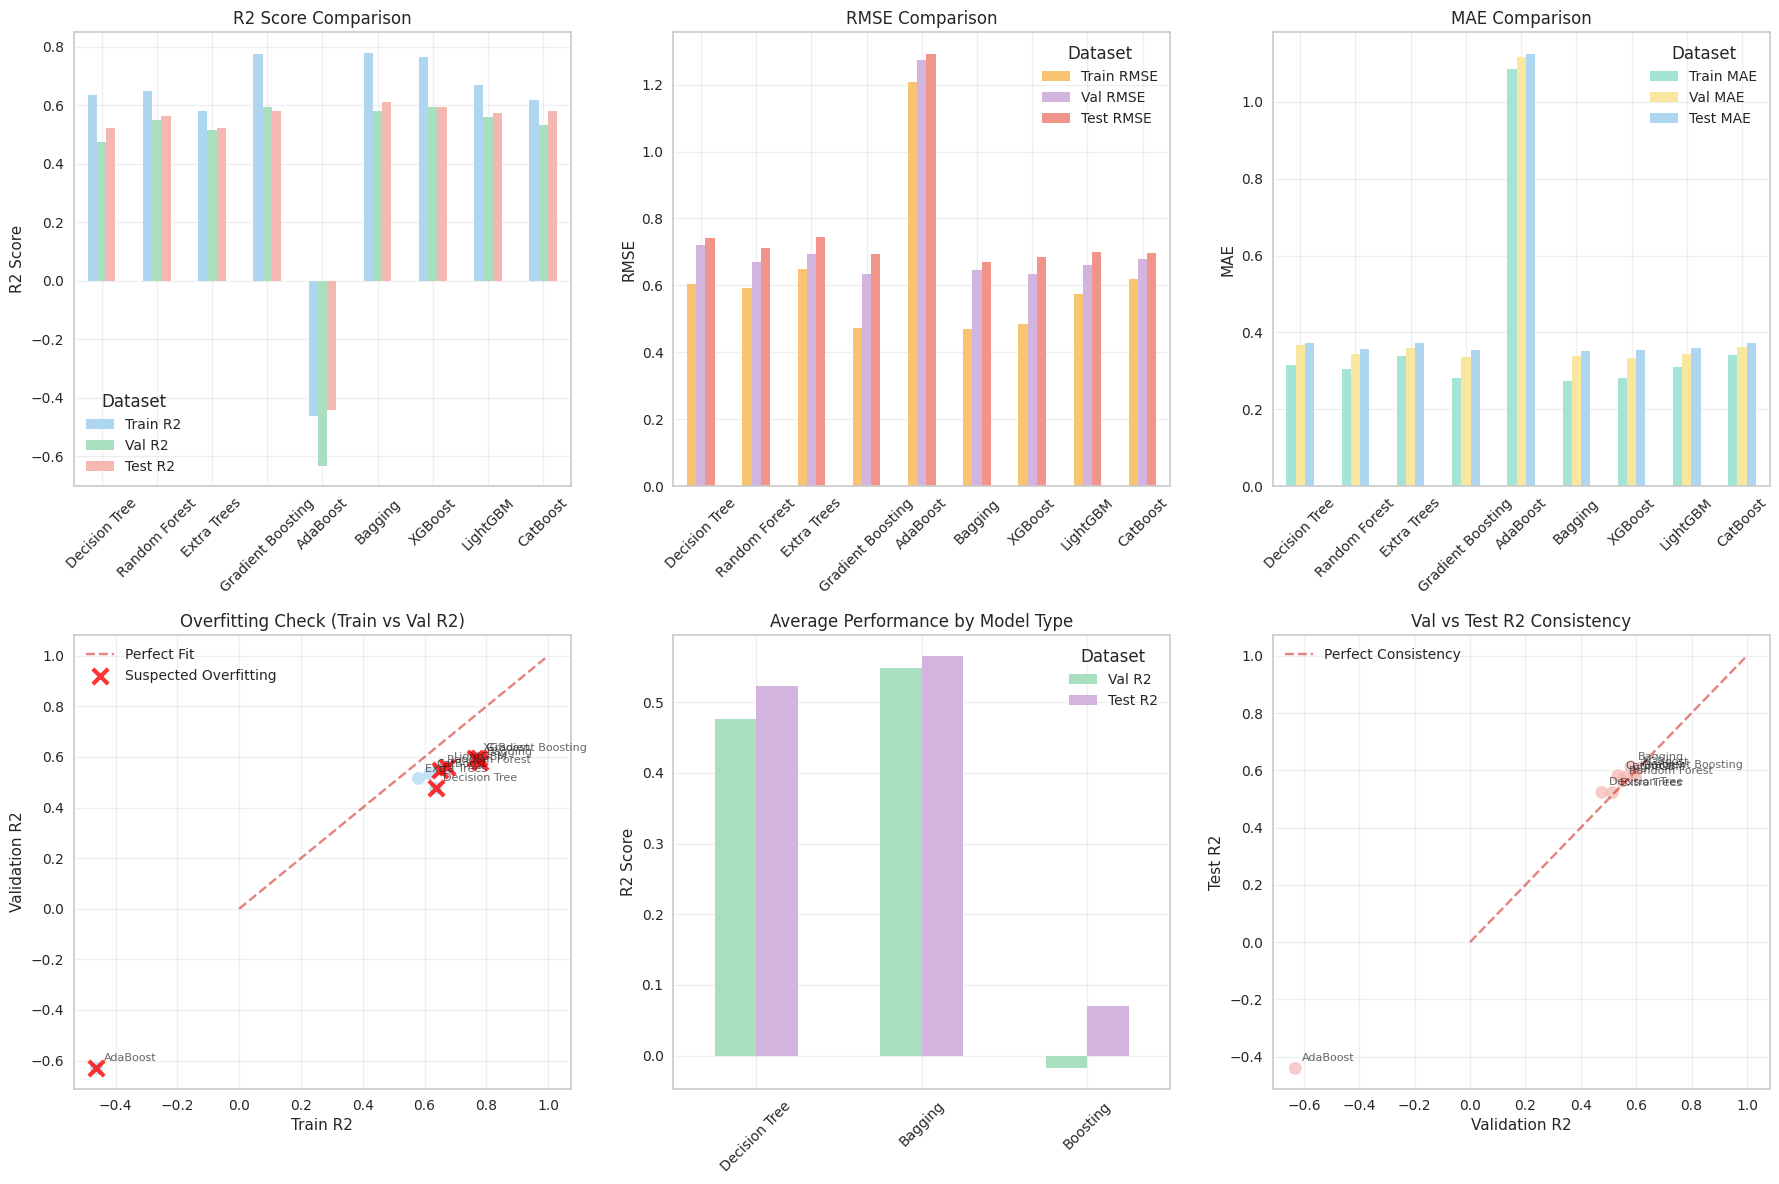

In [17]:
print("="*60)
print("📊 모델 성능 종합 분석 및 시각화")
print("="*60)

# 시각화를 위한 그래프 준비
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1-1. R2 점수 비교
r2_data = results_df[['Train R2', 'Val R2', 'Test R2']]
r2_data.plot(kind='bar', ax=axes[0,0],
             color=[pastel_colors['blue'], pastel_colors['green'], pastel_colors['pink']])
axes[0,0].set_title('R2 Score Comparison', fontsize=12)
axes[0,0].set_ylabel('R2 Score')
axes[0,0].legend(title='Dataset')
axes[0,0].tick_params(axis='x', rotation=45)
axes[0,0].grid(True, alpha=0.3)

# 1-2. RMSE 비교
rmse_data = results_df[['Train RMSE', 'Val RMSE', 'Test RMSE']]
rmse_data.plot(kind='bar', ax=axes[0,1],
               color=[pastel_colors['orange'], pastel_colors['purple'], pastel_colors['coral']])
axes[0,1].set_title('RMSE Comparison', fontsize=12)
axes[0,1].set_ylabel('RMSE')
axes[0,1].legend(title='Dataset')
axes[0,1].tick_params(axis='x', rotation=45)
axes[0,1].grid(True, alpha=0.3)

# 1-3. MAE 비교
mae_data = results_df[['Train MAE', 'Val MAE', 'Test MAE']]
mae_data.plot(kind='bar', ax=axes[0,2],
              color=[pastel_colors['mint'], pastel_colors['yellow'], pastel_colors['blue']])
axes[0,2].set_title('MAE Comparison', fontsize=12)
axes[0,2].set_ylabel('MAE')
axes[0,2].legend(title='Dataset')
axes[0,2].tick_params(axis='x', rotation=45)
axes[0,2].grid(True, alpha=0.3)

# 1-4. 과적합 체크 (Train vs Val R2)
axes[1,0].scatter(results_df['Train R2'], results_df['Val R2'],
                  c=[pastel_colors['blue'] for _ in range(len(results_df))],
                  alpha=0.7, s=80)
axes[1,0].plot([0, 1], [0, 1], 'r--', alpha=0.5, label='Perfect Fit')
axes[1,0].set_xlabel('Train R2')
axes[1,0].set_ylabel('Validation R2')
axes[1,0].set_title('Overfitting Check (Train vs Val R2)', fontsize=12)
axes[1,0].grid(True, alpha=0.3)

# 과적합 모델 강조 표시
overfitted = results_df[results_df['Train R2'] - results_df['Val R2'] > 0.1]
if not overfitted.empty:
    axes[1,0].scatter(overfitted['Train R2'], overfitted['Val R2'],
                      c='red', s=120, alpha=0.8, marker='x',
                      label='Suspected Overfitting', linewidth=3)
axes[1,0].legend()

# 모델별 이름 표시
for i, name in enumerate(results_df.index):
    axes[1,0].annotate(name,
                       (results_df.iloc[i]['Train R2'], results_df.iloc[i]['Val R2']),
                       xytext=(5, 5), textcoords='offset points',
                       fontsize=8, alpha=0.7)

# 1-5. 모델 타입별 성능 분석
model_types = {
    'Decision Tree': ['Decision Tree'],
    'Bagging': ['Random Forest', 'Extra Trees', 'Bagging'],
    'Boosting': ['Gradient Boosting', 'AdaBoost']
}

type_performance = {}
for model_type, models in model_types.items():
    type_models = [m for m in models if m in results_df.index]
    if type_models:
        type_performance[model_type] = {
            'Val R2': results_df.loc[type_models, 'Val R2'].mean(),
            'Test R2': results_df.loc[type_models, 'Test R2'].mean()
        }

type_df = pd.DataFrame(type_performance).T
type_df.plot(kind='bar', ax=axes[1,1],
             color=[pastel_colors['green'], pastel_colors['purple']])
axes[1,1].set_title('Average Performance by Model Type', fontsize=12)
axes[1,1].set_ylabel('R2 Score')
axes[1,1].legend(title='Dataset')
axes[1,1].tick_params(axis='x', rotation=45)
axes[1,1].grid(True, alpha=0.3)

# 1-6. Val vs Test R2 일관성 체크
axes[1,2].scatter(results_df['Val R2'], results_df['Test R2'],
                  c=[pastel_colors['pink'] for _ in range(len(results_df))],
                  alpha=0.7, s=80)
axes[1,2].plot([0, 1], [0, 1], 'r--', alpha=0.5, label='Perfect Consistency')
axes[1,2].set_xlabel('Validation R2')
axes[1,2].set_ylabel('Test R2')
axes[1,2].set_title('Val vs Test R2 Consistency', fontsize=12)
axes[1,2].grid(True, alpha=0.3)
axes[1,2].legend()

# 모델별 이름 표시
for i, name in enumerate(results_df.index):
    axes[1,2].annotate(name,
                       (results_df.iloc[i]['Val R2'], results_df.iloc[i]['Test R2']),
                       xytext=(5, 5), textcoords='offset points',
                       fontsize=8, alpha=0.7)

plt.tight_layout()
plt.show()

### 3.3 모델 하이퍼파라미터 튜닝

In [ ]:
# =============================================================================
# 모델 하이퍼파라미터 튜닝
# =============================================================================

print("="*60)
print("⚙️ 모든 모델 하이퍼파라미터 튜닝 시작")
print("="*60)

# 모델별 하이퍼파라미터 그리드 정의
param_grids = {
    'Decision Tree': {
        'max_depth': [5, 10, 15, 20],
        'min_samples_split': [5, 10, 20, 50],
        'min_samples_leaf': [2, 5, 10, 20],
        'max_features': ['sqrt', 'log2'],
        'criterion': ['squared_error', 'friedman_mse']
    },

    'Random Forest': {
        'n_estimators': [50, 100, 200, 300],
        'max_depth': [5, 10, 15, 20],
        'min_samples_split': [5, 10, 20],
        'min_samples_leaf': [2, 5, 10],
        'max_features': ['sqrt', 'log2'],
        'bootstrap': [True, False]
    },

    'Extra Trees': {
        'n_estimators': [50, 100, 200, 300],
        'max_depth': [5, 10, 15, 20],
        'min_samples_split': [5, 10, 20],
        'min_samples_leaf': [2, 5, 10],
        'max_features': ['sqrt', 'log2'],
        'bootstrap': [True, False]
    },

    'Gradient Boosting': {
        'n_estimators': [50, 100, 150, 200],
        'learning_rate': [0.01, 0.05, 0.1, 0.15, 0.2],
        'max_depth': [3, 5, 7, 9],
        'subsample': [0.7, 0.8, 0.9, 1.0],
        'min_samples_split': [5, 10, 20],
        'min_samples_leaf': [2, 5, 10]
    },

    'AdaBoost': {
        'n_estimators': [25, 50, 100, 150, 200],
        'learning_rate': [0.1, 0.5, 1.0, 1.5, 2.0],
        'estimator__max_depth': [1, 3, 5, 7],
        'estimator__min_samples_split': [5, 10, 20],
        'estimator__min_samples_leaf': [2, 5, 10]
    },

    'Bagging': {
        'n_estimators': [50, 100, 200, 300],
        'max_samples': [0.5, 0.7, 0.8, 1.0],
        'max_features': [0.5, 0.7, 0.8, 1.0],
        'estimator__max_depth': [5, 10, 15, 20],
        'estimator__min_samples_split': [5, 10, 20],
        'estimator__min_samples_leaf': [2, 5, 10]
    },
    'XGBoost': {
        'n_estimators': [50, 100, 150, 200],
        'learning_rate': [0.01, 0.05, 0.1, 0.15, 0.2],
        'max_depth': [3, 5, 7, 9],
        'subsample': [0.7, 0.8, 0.9, 1.0],
        'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
        'reg_alpha': [0, 0.01, 0.1, 1.0],          # L1 정규화
        'reg_lambda': [0, 0.01, 0.1, 1.0],         # L2 정규화
        'min_child_weight': [1, 3, 5, 7]           # 리프 노드 최소 가중치
    },

    'LightGBM': {
        'n_estimators': [50, 100, 150, 200],
        'learning_rate': [0.01, 0.05, 0.1, 0.15, 0.2],
        'max_depth': [3, 5, 7, 9, -1],             # -1은 제한 없음
        'subsample': [0.7, 0.8, 0.9, 1.0],
        'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
        'reg_alpha': [0, 0.01, 0.1, 1.0],          # L1 정규화
        'reg_lambda': [0, 0.01, 0.1, 1.0],         # L2 정규화
        'num_leaves': [31, 63, 127, 255],          # 리프 노드 수
        'min_child_samples': [5, 10, 20, 50]       # 리프 노드 최소 샘플 수
    },

    'CatBoost': {
        'iterations': [50, 100, 150, 200],          # n_estimators와 동일
        'learning_rate': [0.01, 0.05, 0.1, 0.15, 0.2],
        'depth': [3, 5, 7, 9],                      # max_depth와 동일
        'subsample': [0.7, 0.8, 0.9, 1.0],
        'colsample_bylevel': [0.7, 0.8, 0.9, 1.0], # 각 레벨에서의 특성 샘플링
        'reg_lambda': [0, 0.01, 0.1, 1.0],         # L2 정규화
        'min_data_in_leaf': [1, 5, 10, 20],        # 리프 노드 최소 샘플 수
        'bootstrap_type': ['Bayesian', 'Bernoulli', 'No']  # 부트스트랩 타입
    }
}

# # 모델별 하이퍼파라미터 그리드 정의
# param_grids = {
#     'Decision Tree': {
#         'max_depth': [5, 10],
#         'min_samples_split': [5, 10]
#     },

#     'Random Forest': {
#         'n_estimators': [50, 100],
#         'max_depth': [5, 10]
#     },

#     'Extra Trees': {
#         'n_estimators': [50, 100],
#         'max_depth': [5, 10]
#     },

#     'Gradient Boosting': {
#         'n_estimators': [50, 100],
#         'learning_rate': [0.01, 0.05]
#     },

#     'AdaBoost': {
#         'n_estimators': [25, 500],
#         'learning_rate': [0.1, 0.5]
#     },

#     'Bagging': {
#         'n_estimators': [50, 100],
#         'max_samples': [0.5, 0.7]
#     },
#     'XGBoost': {
#         'n_estimators': [50, 100],
#         'learning_rate': [0.01, 0.05],
#     },

#     'LightGBM': {
#         'n_estimators': [50, 100],
#         'learning_rate': [0.01, 0.05],
#     },

#     'CatBoost': {
#         'iterations': [50, 100],
#         'learning_rate': [0.01, 0.05],
#     }
# }


# 튜닝 결과를 저장할 딕셔너리
tuned_models = {}
tuning_results = {}

# 각 모델별로 하이퍼파라미터 튜닝 수행
for model_name, base_model in algorithms.items():
    if model_name in param_grids:
        print(f"\n🔧 {model_name} 튜닝 중...")

        # 총 조합 수 계산
        total_combinations = 1
        for param_values in param_grids[model_name].values():
            total_combinations *= len(param_values)
        print(f"   총 파라미터 조합 수: {total_combinations:,}")

        start_time = datetime.now()

        # GridSearchCV 사용 (모든 조합 탐색)
        grid_search = GridSearchCV(
            estimator=base_model,
            param_grid=param_grids[model_name],
            cv=5,               # 5-fold 교차검증
            scoring='r2',
            n_jobs=-1,          # 모든 CPU 코어 사용
            verbose=0
        )

        # 튜닝 실행
        grid_search.fit(X_train, y_train)

        # 최적 모델 저장
        best_model = grid_search.best_estimator_
        tuned_models[f"{model_name}_Tuned"] = best_model

        # 성능 평가
        train_score = best_model.score(X_train, y_train)
        val_score = best_model.score(X_val, y_val)
        test_score = best_model.score(X_test, y_test)

        # 원본 모델과 비교
        original_model = trained_models[model_name]
        original_val_score = original_model.score(X_val, y_val)
        original_test_score = original_model.score(X_test, y_test)

        # 결과 저장
        tuning_results[model_name] = {
            'best_params': grid_search.best_params_,
            'best_cv_score': grid_search.best_score_,
            'original_val_r2': original_val_score,
            'tuned_val_r2': val_score,
            'val_improvement': val_score - original_val_score,
            'original_test_r2': original_test_score,
            'tuned_test_r2': test_score,
            'test_improvement': test_score - original_test_score,
            'tuning_time': (datetime.now() - start_time).total_seconds()
        }

        # 결과 출력
        end_time = datetime.now()
        duration = (end_time - start_time).total_seconds()

        print(f"   ✅ 완료 (소요시간: {duration:.1f}초)")
        print(f"   최적 CV 점수: {grid_search.best_score_:.4f}")
        print(f"   검증 R2: {original_val_score:.4f} → {val_score:.4f} ({val_score - original_val_score:+.4f})")
        print(f"   테스트 R2: {original_test_score:.4f} → {test_score:.4f} ({test_score - original_test_score:+.4f})")

    else:
        print(f"⚠️ {model_name}에 대한 파라미터 그리드가 정의되지 않았습니다.")


⚙️ 모든 모델 하이퍼파라미터 튜닝 시작

🔧 Decision Tree 튜닝 중...
   총 파라미터 조합 수: 4
   ✅ 완료 (소요시간: 1.0초)
   최적 CV 점수: 0.4506
   검증 R2: 0.4761 → 0.4761 (+0.0000)
   테스트 R2: 0.5229 → 0.5229 (+0.0000)

🔧 Random Forest 튜닝 중...
   총 파라미터 조합 수: 4
   ✅ 완료 (소요시간: 10.0초)
   최적 CV 점수: 0.5277
   검증 R2: 0.5492 → 0.5461 (-0.0032)
   테스트 R2: 0.5629 → 0.5572 (-0.0057)

🔧 Extra Trees 튜닝 중...
   총 파라미터 조합 수: 4
   ✅ 완료 (소요시간: 3.3초)
   최적 CV 점수: 0.5043
   검증 R2: 0.5149 → 0.5120 (-0.0029)
   테스트 R2: 0.5224 → 0.5197 (-0.0026)

🔧 Gradient Boosting 튜닝 중...
   총 파라미터 조합 수: 4
   ✅ 완료 (소요시간: 27.6초)
   최적 CV 점수: 0.5555
   검증 R2: 0.5951 → 0.5728 (-0.0224)
   테스트 R2: 0.5824 → 0.5875 (+0.0051)

🔧 AdaBoost 튜닝 중...
   총 파라미터 조합 수: 4
   ✅ 완료 (소요시간: 76.6초)
   최적 CV 점수: 0.4908
   검증 R2: -0.6312 → 0.4946 (+1.1258)
   테스트 R2: -0.4411 → 0.5217 (+0.9628)

🔧 Bagging 튜닝 중...
   총 파라미터 조합 수: 4
   ✅ 완료 (소요시간: 14.6초)
   최적 CV 점수: 0.5529
   검증 R2: 0.5815 → 0.5763 (-0.0052)
   테스트 R2: 0.6119 → 0.6099 (-0.0020)

🔧 XGBoost 튜닝 중...
   총 파라미터 조합 수: 4
 

In [19]:
# =============================================================================
# 튜닝된 모델 결과 요약
# =============================================================================

print("="*60)
print("📊 하이퍼파라미터 튜닝 결과 요약")
print("="*60)

# 결과 DataFrame 생성
tuning_summary = []
for model_name, results in tuning_results.items():
    tuning_summary.append({
        'Model': model_name,
        'Original_Val_R2': results['original_val_r2'],
        'Tuned_Val_R2': results['tuned_val_r2'],
        'Val_Improvement': results['val_improvement'],
        'Original_Test_R2': results['original_test_r2'],
        'Tuned_Test_R2': results['tuned_test_r2'],
        'Test_Improvement': results['test_improvement'],
        'Best_CV_Score': results['best_cv_score'],
        'Tuning_Time(s)': results['tuning_time']
    })

tuning_df = pd.DataFrame(tuning_summary)
tuning_df = tuning_df.set_index('Model')

# 결과 출력
print("\n🏆 튜닝 전후 성능 비교:")
display_columns = ['Original_Val_R2', 'Tuned_Val_R2', 'Val_Improvement',
                  'Original_Test_R2', 'Tuned_Test_R2', 'Test_Improvement']


print(f"\n⏱️ 튜닝 소요시간:")
print(tuning_df[['Tuning_Time(s)']].round(1))

# 최고 성능 모델 식별
best_tuned_model = tuning_df['Tuned_Test_R2'].idxmax()
best_score = tuning_df.loc[best_tuned_model, 'Tuned_Test_R2']

print(f"\n🥇 최고 성능 모델: {best_tuned_model}")
print(f"   테스트 R2 점수: {best_score:.4f}")

# 각 모델의 최적 파라미터 출력
print(f"\n🔧 최적 하이퍼파라미터:")
for model_name, results in tuning_results.items():
    print(f"\n{model_name}:")
    for param, value in results['best_params'].items():
        print(f"   {param}: {value}")

tuning_df[display_columns].round(4)

📊 하이퍼파라미터 튜닝 결과 요약

🏆 튜닝 전후 성능 비교:

⏱️ 튜닝 소요시간:
                   Tuning_Time(s)
Model                            
Decision Tree                 1.0
Random Forest                10.0
Extra Trees                   3.3
Gradient Boosting            27.6
AdaBoost                     76.6
Bagging                      14.6
XGBoost                      44.1
LightGBM                    153.8
CatBoost                     10.8

🥇 최고 성능 모델: Bagging
   테스트 R2 점수: 0.6099

🔧 최적 하이퍼파라미터:

Decision Tree:
   max_depth: 10
   min_samples_split: 5

Random Forest:
   max_depth: 10
   n_estimators: 50

Extra Trees:
   max_depth: 10
   n_estimators: 50

Gradient Boosting:
   learning_rate: 0.05
   n_estimators: 100

AdaBoost:
   learning_rate: 0.1
   n_estimators: 25

Bagging:
   max_samples: 0.7
   n_estimators: 100

XGBoost:
   learning_rate: 0.05
   n_estimators: 100

LightGBM:
   learning_rate: 0.05
   n_estimators: 100

CatBoost:
   iterations: 100
   learning_rate: 0.05


,Original_Val_R2,Tuned_Val_R2,Val_Improvement,Original_Test_R2,Tuned_Test_R2,Test_Improvement
Model,,,,,,
Decision Tree,0.4761,0.4761,0.0000,0.5229,0.5229,0.0000
Random Forest,0.5492,0.5461,-0.0032,0.5629,0.5572,-0.0057
Extra Trees,0.5149,0.5120,-0.0029,0.5224,0.5197,-0.0026
Gradient Boosting,0.5951,0.5728,-0.0224,0.5824,0.5875,0.0051
AdaBoost,-0.6312,0.4946,1.1258,-0.4411,0.5217,0.9628
Bagging,0.5815,0.5763,-0.0052,0.6119,0.6099,-0.0020
XGBoost,0.5942,0.5712,-0.0230,0.5938,0.5918,-0.0020
LightGBM,0.5598,0.5359,-0.0238,0.5756,0.5578,-0.0178
CatBoost,0.5344,0.4930,-0.0414,0.5809,0.5478,-0.0331


In [20]:
# =============================================================================
# 튜닝된 모델들 재평가
# =============================================================================

print("="*60)
print("📈 튜닝된 모델 전체 성능 평가")
print("="*60)

# 모든 튜닝된 모델 평가
all_models = {**trained_models, **tuned_models}
final_results = []

for name, model in all_models.items():
    # 예측
    y_train_pred = model.predict(X_train)
    y_val_pred = model.predict(X_val)
    y_test_pred = model.predict(X_test)

    # 성능 지표 계산
    result = {
        'Model': name,
        'Train_R2': model.score(X_train, y_train),
        'Val_R2': model.score(X_val, y_val),
        'Test_R2': model.score(X_test, y_test),
        'Train_RMSE': np.sqrt(mean_squared_error(y_train, y_train_pred)),
        'Val_RMSE': np.sqrt(mean_squared_error(y_val, y_val_pred)),
        'Test_RMSE': np.sqrt(mean_squared_error(y_test, y_test_pred)),
        'Train_MAE': mean_absolute_error(y_train, y_train_pred),
        'Val_MAE': mean_absolute_error(y_val, y_val_pred),
        'Test_MAE': mean_absolute_error(y_test, y_test_pred)
    }
    final_results.append(result)

# 최종 결과 DataFrame
final_df = pd.DataFrame(final_results).set_index('Model')

# 원본과 튜닝 모델 분리하여 출력
original_models = [col for col in final_df.index if '_Tuned' not in col]
tuned_models_list = [col for col in final_df.index if '_Tuned' in col]

print("원본 모델 성능:")
print(final_df.loc[original_models, ['Val_R2', 'Test_R2', 'Test_RMSE', 'Test_MAE']].round(4))

print("\n튜닝된 모델 성능:")
print(final_df.loc[tuned_models_list, ['Val_R2', 'Test_R2', 'Test_RMSE', 'Test_MAE']].round(4))

# 최종 최고 성능 모델
best_final_model = final_df['Test_R2'].idxmax()
print(f"\n🏆 전체 최고 성능 모델: {best_final_model}")
print(f"   테스트 R2: {final_df.loc[best_final_model, 'Test_R2']:.4f}")
print(f"   테스트 RMSE: {final_df.loc[best_final_model, 'Test_RMSE']:.4f}")
print(f"   테스트 MAE: {final_df.loc[best_final_model, 'Test_MAE']:.4f}")

📈 튜닝된 모델 전체 성능 평가
원본 모델 성능:
                   Val_R2  Test_R2  Test_RMSE  Test_MAE
Model                                                  
Decision Tree      0.4761   0.5229     0.7431    0.3734
Random Forest      0.5492   0.5629     0.7113    0.3581
Extra Trees        0.5149   0.5224     0.7435    0.3737
Gradient Boosting  0.5951   0.5824     0.6952    0.3554
AdaBoost          -0.6312  -0.4411     1.2915    1.1243
Bagging            0.5815   0.6119     0.6702    0.3506
XGBoost            0.5942   0.5938     0.6856    0.3537
LightGBM           0.5598   0.5756     0.7009    0.3605
CatBoost           0.5344   0.5809     0.6965    0.3714

튜닝된 모델 성능:
                         Val_R2  Test_R2  Test_RMSE  Test_MAE
Model                                                        
Decision Tree_Tuned      0.4761   0.5229     0.7431    0.3734
Random Forest_Tuned      0.5461   0.5572     0.7159    0.3590
Extra Trees_Tuned        0.5120   0.5197     0.7456    0.3740
Gradient Boosting_Tuned  0.5728   

## 4. AutoML framework(pycaret)

### 4.1 Pycaret 설정

In [21]:
pycaret.__version__

'3.3.2'

In [22]:
print("="*70)
print("⚙️ PyCaret 환경 설정 (Initialization)")
print("="*70)

# 시간 기록
setup_start_time = time.time()

# 환경 설정
reg_setup = setup(
    # 기본 설정
    data=df_processed,                          # 데이터셋
    target=target_col,               # 타겟 변수
    train_size=0.8,                  # 훈련 데이터 비율 (0.2는 자동으로 테스트)
    session_id=42,                   # 재현 가능한 결과를 위한 시드

    # 데이터 분할 설정
    data_split_shuffle=True,         # 데이터 분할 시 셔플
    data_split_stratify=False,       # y값 구축에서 class 고려하여 설정. 회귀에서는 False

    # 전처리 활성화
    preprocess=True,                 # 전처리 활성화

    # 결측치 처리
    imputation_type='iterative',     # 'simple', 'iterative', 'knn' 중 선택
    numeric_imputation='mean',       # 수치형: 'mean', 'median', 'mode', 'knn'
    categorical_imputation='mode',   # 범주형: 'mode', 'constant'

    # 스케일링 및 정규화
    normalize=True,                  # 정규화 활성화
    normalize_method='minmax',       # 'zscore', 'minmax', 'maxabs', 'robust'

    # 이상치 처리
    remove_outliers=True,            # 이상치 제거
    outliers_method='iforest',       # 'iforest', 'ee', 'lof', 'svm', 'pca'
    outliers_threshold=0.05,         # 이상치 비율 임계값

    # 교차검증 설정
    fold_strategy='kfold',           # 'kfold', 'stratifiedkfold', 'groupkfold', 'timeseries'
    fold=5,                          # 교차검증 fold 수
    fold_shuffle=True,               # fold 셔플

    # 성능 최적화
    n_jobs=-1,                       # 모든 CPU 코어 사용
    use_gpu=False,                   # GPU 사용 (CUDA 설정 필요)

    # 실험 관리
    experiment_name='advanced_regression_ml',  # 실험 이름
    log_experiment=False,            # MLflow 로깅 비활성화
    log_plots=False,                 # 플롯 로깅 비활성화
    log_profile=False,               # 프로파일 로깅 비활성화
    log_data=False,                  # 데이터 로깅 비활성화

    # 고급 설정 (필요시 활성화)
    # ignore_features=None,          # 무시할 특성들 (리스트로 지정)
    # keep_features=None,            # 유지할 특성들 (리스트로 지정)
    # numeric_features=None,         # 수치형 변수 강제 지정
    # categorical_features=None,     # 범주형 변수 강제 지정
    # date_features=None,            # 날짜 변수 지정
    # text_features=None,            # 텍스트 변수 지정
    # ordinal_features=None,         # 순서형 범주 변수
)

⚙️ PyCaret 환경 설정 (Initialization)


,Description,Value
0,Session id,42
1,Target,y1
2,Target type,Regression
3,Original data shape,"(28812, 17)"
4,Transformed data shape,"(27660, 17)"
5,Transformed train set shape,"(21897, 17)"
6,Transformed test set shape,"(5763, 17)"
7,Numeric features,16
8,Preprocess,True
9,Imputation type,iterative


### 4.2 Pycaret 모델 학습 및 비교

In [23]:
# =============================================================================
# 4. 모델 비교 및 선택
# =============================================================================

print("\n" + "="*70)
print("🏆 모델 비교 및 성능 평가")
print("="*70)

# 모델 비교 실행
comparison_start_time = time.time()

# 사용할 모델들 정의
all_models = [
    'lr',        # Linear Regression
    # 'ridge',     # Ridge Regression
    # 'lasso',     # Lasso Regression
    # 'en',        # Elastic Net
    # 'lar',       # Least Angle Regression
    # 'llar',      # Lasso Least Angle Regression
    # 'omp',       # Orthogonal Matching Pursuit
    # 'br',        # Bayesian Ridge
    # 'ard',       # Automatic Relevance Determination
    # 'par',       # Passive Aggressive Regressor
    # 'ransac',    # RANSAC Regressor
    # 'tr',        # TheilSen Regressor
    # 'huber',     # Huber Regressor
    # 'kr',        # Kernel Ridge
    # 'svm',       # SVM - Linear Kernel
    # 'knn',       # K Neighbors Regressor
    'dt',        # Decision Tree
    'rf',        # Random Forest
    'et',        # Extra Trees
    'ada',       # AdaBoost
    'gbr',       # Gradient Boosting
    'mlp',       # Multi Level Perceptron
    # 'dummy',     # Dummy Regressor
    'xgboost',   # XGBoost
    # 'lightgbm'   # LightGBM
]

models_comparison = compare_models(
        include=all_models,              # 포함할 모델들
        exclude=None,                    # 제외할 모델들
        fold=5,                          # 교차검증 fold 수
        round=4,                         # 소수점 자릿수
        cross_validation=True,           # 교차검증 활성화
        sort='R2',                       # 정렬 기준 ('MAE', 'MSE', 'RMSE', 'R2', 'RMSLE', 'MAPE')
        n_select=10,                     # 선택할 모델 수
        budget_time=None,                # 시간 제한 (분 단위)
        turbo=True,                      # 터보 모드 (빠른 실행)
        errors='ignore',                 # 에러 처리 방식
        fit_kwargs=None,                 # 추가 fit 파라미터
    )

print(f"✅ 고급 설정 모델 비교 완료!")


🏆 모델 비교 및 성능 평가


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
et,Extra Trees Regressor,0.0425,0.0086,0.0929,0.4848,0.0678,125.2410,1.5920
rf,Random Forest Regressor,0.0431,0.0088,0.0937,0.4769,0.0684,133.0623,2.6020
xgboost,Extreme Gradient Boosting,0.0447,0.0091,0.0953,0.4579,0.0700,122.5299,0.3200
gbr,Gradient Boosting Regressor,0.0477,0.0095,0.0977,0.4314,0.0717,137.5529,0.9100
mlp,MLP Regressor,0.0501,0.0102,0.1011,0.3917,0.0744,150.4666,0.3780
lr,Linear Regression,0.0559,0.0117,0.1080,0.3056,0.0802,215.1993,0.5880
dt,Decision Tree Regressor,0.0559,0.0148,0.1215,0.1171,0.0903,126.6599,0.7480
ada,AdaBoost Regressor,0.1289,0.0261,0.1584,-0.5679,0.1298,234.5613,0.4440


✅ 고급 설정 모델 비교 완료!


In [24]:
# K-fold 시 비교 결과 확인
comparison_results = pull()
print(f"\n🏆 상위 10개 모델 성능:")
display(comparison_results)

# K-fold 시 최고 성능 모델 정보
best_model_info = comparison_results.iloc[0]
best_model_name = best_model_info.name
print(f"\n🥇 최고 성능 모델: {best_model_name}")
print(f"   • R2 Score: {best_model_info['R2']:.4f}")
print(f"   • MAE: {best_model_info['MAE']:.4f}")
print(f"   • MSE: {best_model_info['MSE']:.4f}")
print(f"   • RMSE: {best_model_info['RMSE']:.4f}")


🏆 상위 10개 모델 성능:


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
et,Extra Trees Regressor,0.0425,0.0086,0.0929,0.4848,0.0678,125.2410,1.592
rf,Random Forest Regressor,0.0431,0.0088,0.0937,0.4769,0.0684,133.0623,2.602
xgboost,Extreme Gradient Boosting,0.0447,0.0091,0.0953,0.4579,0.0700,122.5299,0.320
gbr,Gradient Boosting Regressor,0.0477,0.0095,0.0977,0.4314,0.0717,137.5529,0.910
mlp,MLP Regressor,0.0501,0.0102,0.1011,0.3917,0.0744,150.4666,0.378
lr,Linear Regression,0.0559,0.0117,0.1080,0.3056,0.0802,215.1993,0.588
dt,Decision Tree Regressor,0.0559,0.0148,0.1215,0.1171,0.0903,126.6599,0.748
ada,AdaBoost Regressor,0.1289,0.0261,0.1584,-0.5679,0.1298,234.5613,0.444



🥇 최고 성능 모델: et
   • R2 Score: 0.4848
   • MAE: 0.0425
   • MSE: 0.0086
   • RMSE: 0.0929


In [25]:
# =============================================================================
# 4. 모델 테스트
# =============================================================================

# 상위 3개 모델 상세 평가
top_3_models = models_comparison[:3]

detailed_test_results = {}

for i, model in enumerate(top_3_models):
    model_name = str(model).split('(')[0]
    print(f"\n🔍 {i+1}번째 모델: {model_name} 상세 분석")

    # PyCaret에서 훈련 데이터 가져오기
    X_train = get_config('X_train')
    y_train = get_config('y_train')

    # 훈련 데이터를 DataFrame으로 결합 (predict_model 요구사항)
    train_data = X_train.copy()
    train_data[target_col] = y_train

    # 훈련 세트 예측
    train_predictions = predict_model(model, data=train_data)
    train_pred_values = train_predictions['prediction_label']
    train_actual_values = train_predictions[target_col]

    # 홀드아웃 테스트 세트 예측
    test_predictions = predict_model(model)
    test_pred_values = test_predictions['prediction_label']
    test_actual_values = test_predictions[target_col]

    # 성능 지표 계산
    train_metrics = {
        'R2': r2_score(train_actual_values, train_pred_values),
        'MAE': mean_absolute_error(train_actual_values, train_pred_values),
        'MSE': mean_squared_error(train_actual_values, train_pred_values),
        'RMSE': np.sqrt(mean_squared_error(train_actual_values, train_pred_values))
    }

    test_metrics = {
        'R2': r2_score(test_actual_values, test_pred_values),
        'MAE': mean_absolute_error(test_actual_values, test_pred_values),
        'MSE': mean_squared_error(test_actual_values, test_pred_values),
        'RMSE': np.sqrt(mean_squared_error(test_actual_values, test_pred_values))
    }

    # 결과 출력
    print(f"   📈 훈련 세트 성능:")
    for metric, value in train_metrics.items():
        print(f"      {metric}: {value:.4f}")

    print(f"   📊 테스트 세트 성능:")
    for metric, value in test_metrics.items():
        print(f"      {metric}: {value:.4f}")

    # 상세 결과에 추가
    if model_name in detailed_test_results:
        detailed_test_results[model_name]['train_metrics'] = train_metrics
        detailed_test_results[model_name]['test_metrics'] = test_metrics
    else:
        detailed_test_results[model_name] = {
            'model': model,
            'train_metrics': train_metrics,
            'test_metrics': test_metrics
        }


🔍 1번째 모델: ExtraTreesRegressor 상세 분석


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Extra Trees Regressor,0.0089,0.0044,0.0666,0.7360,0.0425,43.9762


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Extra Trees Regressor,0.0409,0.0070,0.0838,0.5089,0.0640,84.4618


   📈 훈련 세트 성능:
      R2: 0.7360
      MAE: 0.0089
      MSE: 0.0044
      RMSE: 0.0666
   📊 테스트 세트 성능:
      R2: 0.5089
      MAE: 0.0409
      MSE: 0.0070
      RMSE: 0.0838

🔍 2번째 모델: RandomForestRegressor 상세 분석


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Random Forest Regressor,0.0216,0.0051,0.0714,0.6966,0.0473,81.1611


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Random Forest Regressor,0.0422,0.0071,0.0844,0.5014,0.0648,97.0421


   📈 훈련 세트 성능:
      R2: 0.6966
      MAE: 0.0216
      MSE: 0.0051
      RMSE: 0.0714
   📊 테스트 세트 성능:
      R2: 0.5014
      MAE: 0.0422
      MSE: 0.0071
      RMSE: 0.0844

🔍 3번째 모델: XGBRegressor 상세 분석


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Extreme Gradient Boosting,0.0330,0.0066,0.0811,0.6091,0.0565,61.5134


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Extreme Gradient Boosting,0.0429,0.0076,0.0873,0.4675,0.0661,73.0326


   📈 훈련 세트 성능:
      R2: 0.6091
      MAE: 0.0330
      MSE: 0.0066
      RMSE: 0.0811
   📊 테스트 세트 성능:
      R2: 0.4675
      MAE: 0.0429
      MSE: 0.0076
      RMSE: 0.0873


### 4.3 Pycaret 모델 상세 비교

In [26]:
# =============================================================================
# 개별 모델 상세 평가
# =============================================================================

print("="*70)
print("🔍 개별 모델 상세 평가")
print("="*70)

# 상위 3개 모델 상세 평가
top_3_models = models_comparison[:3]
detailed_results = {}

for i, model in enumerate(top_3_models):
    model_name = str(model).split('(')[0]

    print(f"\n📊 {i+1}번째 모델: {model_name}")
    evaluation_start_time = time.time()

    evaluation_results = evaluate_model(
        estimator=model,                 # 평가할 모델
        fold=5,                          # 교차검증 fold 수
        fit_kwargs=None,                 # 추가 fit 파라미터
    )

    evaluation_time = time.time() - evaluation_start_time

    # 평가 결과 저장
    eval_metrics = pull()
    detailed_results[model_name] = {
        'model': model,
        'metrics': eval_metrics,
        'evaluation_time': evaluation_time
    }

🔍 개별 모델 상세 평가

📊 1번째 모델: ExtraTreesRegressor


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…


📊 2번째 모델: RandomForestRegressor


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…


📊 3번째 모델: XGBRegressor


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

### 4.4 Pycaret 모델 하이퍼파라미터 튜닝

In [27]:
print("\n" + "="*70)
print("⚙️ 하이퍼파라미터 튜닝")
print("="*70)

# 최고 성능 모델 선택
best_model = models_comparison[0]
model_name = str(best_model).split('(')[0]

print(f"🎯 선택된 모델: {model_name}")
print(f"📊 튜닝 전 성능: R2 = {comparison_results.iloc[0]['R2']:.4f}")

# 하이퍼파라미터 튜닝 실행
print(f"\n🔧 {model_name} 하이퍼파라미터 튜닝 시작...")
tuning_start_time = time.time()

# 원본 모델 성능 저장 (기준점)
original_r2 = comparison_results.iloc[0]['R2']

# 최적화된 하이퍼파라미터 튜닝
tuning_methods = [
    {'name': 'random', 'search_library': 'scikit-learn', 'search_algorithm': 'random'},
    # {'name': 'grid', 'search_library': 'scikit-learn', 'search_algorithm': 'grid'},
]

tuned_models = {}

for method_config in tuning_methods:
    method_name = method_config['name']
    print(f"\n🔄 {method_name.upper()} 튜닝 실행 중...")

    try:
        if method_name == 'random':
            # Random Search
            tuned_model = tune_model(
                estimator=best_model,            # 튜닝할 모델
                optimize='R2',                   # 최적화 지표
                fold=5,                          # 교차검증 fold
                round=4,                         # 소수점 자릿수
                n_iter=10,                       # 반복 횟수 증가 (2 → 10)
                search_library='scikit-learn',   # 검색 라이브러리
                search_algorithm='random',       # 검색 알고리즘
                choose_better=True,              # 더 나은 모델 선택
                verbose=False,                   # 출력 제어
                tuner_verbose=False              # 튜너 출력 제어
            )

        elif method_name == 'grid':
            # Grid Search
            tuned_model = tune_model(
                estimator=best_model,
                optimize='R2',
                fold=3,                          # 시간 절약을 위해 3-fold
                round=4,
                search_library='scikit-learn',
                search_algorithm='grid',
                choose_better=True,
                verbose=False,
                tuner_verbose=False
            )

        # 튜닝 결과 확인
        tuning_results = pull()
        tuned_r2 = tuning_results['R2'].mean()

        print(f"   📊 튜닝 결과 R2: {tuned_r2:.4f}")
        print(f"   📊 원본 모델 R2: {original_r2:.4f}")

        # 튜닝된 모델이 원본보다 나은지 확인
        if tuned_r2 > original_r2:
            tuned_models[method_name] = {
                'model': tuned_model,
                'results': tuning_results,
                'best_r2': tuned_r2
            }

            print(f"   ✅ {method_name.upper()} 튜닝 성공!")
            print(f"      튜닝 후 R2: {tuned_r2:.4f}")
            print(f"      성능 향상: +{tuned_r2 - original_r2:.4f}")
            print(f"      표준편차: ±{tuning_results['R2'].std():.4f}")
        else:
            print(f"   ⚠️ {method_name.upper()} 튜닝 결과가 원본보다 나쁨")
            print(f"      튜닝 후 R2: {tuned_r2:.4f} (원본: {original_r2:.4f})")
            print(f"      → 원본 모델 유지")

            # 원본 모델을 튜닝된 모델로 저장
            tuned_models[method_name] = {
                'model': best_model,  # 원본 모델 사용
                'results': tuning_results,
                'best_r2': original_r2  # 원본 성능 사용
            }

    except Exception as e:
        print(f"   ❌ {method_name.upper()} 튜닝 실패: {str(e)}")
        print(f"   🔄 원본 모델 유지")

        # 실패 시 원본 모델 사용
        tuned_models[method_name] = {
            'model': best_model,
            'results': None,
            'best_r2': original_r2
        }

tuning_time = time.time() - tuning_start_time
print(f"\n✅ 하이퍼파라미터 튜닝 완료! (총 소요시간: {tuning_time:.2f}초)")

# 최고 튜닝 결과 선택 (안전한 방식)
if tuned_models:
    best_tuning_method = max(tuned_models.keys(),
                           key=lambda x: tuned_models[x]['best_r2'])
    best_tuned_model = tuned_models[best_tuning_method]['model']
    best_tuned_r2 = tuned_models[best_tuning_method]['best_r2']

    print(f"\n🏆 최고 튜닝 결과:")
    print(f"   방법: {best_tuning_method.upper()}")
    print(f"   최종 R2: {best_tuned_r2:.4f}")

else:
    print(f"\n⚠️ 튜닝 실패. 원본 모델 사용")
    best_tuned_model = best_model
    best_tuned_r2 = original_r2


⚙️ 하이퍼파라미터 튜닝
🎯 선택된 모델: ExtraTreesRegressor
📊 튜닝 전 성능: R2 = 0.4848

🔧 ExtraTreesRegressor 하이퍼파라미터 튜닝 시작...

🔄 RANDOM 튜닝 실행 중...
   📊 튜닝 결과 R2: 0.2915
   📊 원본 모델 R2: 0.4848
   ⚠️ RANDOM 튜닝 결과가 원본보다 나쁨
      튜닝 후 R2: 0.2915 (원본: 0.4848)
      → 원본 모델 유지

✅ 하이퍼파라미터 튜닝 완료! (총 소요시간: 97.42초)

🏆 최고 튜닝 결과:
   방법: RANDOM
   최종 R2: 0.4848


### 4.5 Pycaret 모델 앙상블

In [28]:
print("="*70)
print("🤝 앙상블 모델 구성")
print("="*70)

# 상위 모델들로 앙상블 구성
ensemble_models = models_comparison[:3]  # 상위 3개 모델 사용
print(f"📋 앙상블에 포함될 모델들:")
for i, model in enumerate(ensemble_models, 1):
    model_name = str(model).split('(')[0]
    print(f"   {i}. {model_name}")

# PyCaret Voting Ensemble
print(f"\n🗳️ Voting Ensemble 생성 중...")
voting_start_time = time.time()

voting_ensemble = blend_models(
    estimator_list=ensemble_models,      # 앙상블할 모델들
    fold=5,                              # 교차검증 fold
    round=4,                             # 소수점 자릿수
    choose_better=True,                  # 더 나은 모델 선택
    optimize='R2',                       # 최적화 지표
    weights=None,                        # 가중치 (None이면 균등)
    fit_kwargs=None,                     # 추가 fit 파라미터
    groups=None,                         # 그룹 교차검증
    verbose=False,                       # 출력 제어
    return_train_score=False             # 훈련 점수 반환 여부
)

voting_time = time.time() - voting_start_time
voting_results = pull()

print(f"✅ Voting Ensemble 완료! (소요시간: {voting_time:.2f}초)")
print(f"   R2 Score: {voting_results['R2'].mean():.4f} (±{voting_results['R2'].std():.4f})")


# PyCaret Stacking Ensemble
print(f"\n🏗️ Stacking Ensemble 생성 중...")
stacking_start_time = time.time()

stacking_ensemble = stack_models(
    estimator_list=ensemble_models,      # 기본 모델들
    meta_model=None,                     # 메타 모델 (None이면 자동 선택)
    fold=5,                              # 교차검증 fold
    round=4,                             # 소수점 자릿수
    restack=True,                        # 리스태킹 활성화
    choose_better=True,                  # 더 나은 모델 선택
    optimize='R2',                       # 최적화 지표
    fit_kwargs=None,                     # 추가 fit 파라미터
    groups=None,                         # 그룹 교차검증
    verbose=False,                       # 출력 제어
    return_train_score=False             # 훈련 점수 반환 여부
)

stacking_time = time.time() - stacking_start_time
stacking_results = pull()

print(f"✅ Stacking Ensemble 완료! (소요시간: {stacking_time:.2f}초)")
print(f"   R2 Score: {stacking_results['R2'].mean():.4f} (±{stacking_results['R2'].std():.4f})")

🤝 앙상블 모델 구성
📋 앙상블에 포함될 모델들:
   1. ExtraTreesRegressor
   2. RandomForestRegressor
   3. XGBRegressor

🗳️ Voting Ensemble 생성 중...
✅ Voting Ensemble 완료! (소요시간: 62.37초)
   R2 Score: 0.4344 (±0.1798)

🏗️ Stacking Ensemble 생성 중...
✅ Stacking Ensemble 완료! (소요시간: 139.80초)
   R2 Score: 0.4365 (±0.1799)


In [29]:
# 앙상블 성능 비교
ensemble_comparison = pd.DataFrame()

# 개별 모델 성능 (상위 5개)
for i, model in enumerate(ensemble_models):
    model_name = str(model).split('(')[0]
    model_r2 = comparison_results.iloc[i]['R2']
    ensemble_comparison[f"{model_name}"] = {'R2': model_r2}

# 튜닝된 모델 성능
if 'best_tuned_model' in locals():
    ensemble_comparison['Tuned_Model'] = {'R2': best_tuned_r2}

# 앙상블 모델 성능
if voting_ensemble is not None:
    ensemble_comparison['Voting_Ensemble'] = {'R2': voting_results['R2'].mean()}

if stacking_ensemble is not None:
    ensemble_comparison['Stacking_Ensemble'] = {'R2': stacking_results['R2'].mean()}

# 결과 DataFrame 변환
ensemble_comparison = ensemble_comparison.T

print(f"\n📊 모든 모델 성능 비교:")
display(ensemble_comparison.round(4))

# 최고 성능 모델 식별
best_overall_model_name = ensemble_comparison['R2'].idxmax()
best_overall_r2 = ensemble_comparison['R2'].max()

print(f"\n🏆 최고 성능 모델: {best_overall_model_name}")
print(f"   R2 Score: {best_overall_r2:.4f}")


📊 모든 모델 성능 비교:


,R2
ExtraTreesRegressor,0.4848
RandomForestRegressor,0.4769
XGBRegressor,0.4579
Tuned_Model,0.4848
Voting_Ensemble,0.4344
Stacking_Ensemble,0.4365



🏆 최고 성능 모델: ExtraTreesRegressor
   R2 Score: 0.4848
